In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import metpy.calc as mpcalc
from metpy.units import units

In [2]:
with open('/home/annierosen16/master_1979_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [3]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

In [4]:
surface_variables_path = "/home/annierosen16/data/era5sgp/era5_sl_surface_terms_full_sgp/"

surface_vars_ds = xr.open_mfdataset(f"{surface_variables_path}*.nc", combine='by_coords')

In [5]:
surface_vars_ds['valid_time'] = surface_vars_ds['valid_time'] - pd.Timedelta(hours=6)

In [6]:
desired_hours = [0, 3, 6, 9, 12, 15, 18, 21]

mask = surface_vars_ds['valid_time'].dt.hour.isin(desired_hours)

filtered_ds = surface_vars_ds.sel(valid_time=surface_vars_ds['valid_time'][mask])

In [7]:
surface_dewpoint = filtered_ds['d2m'].metpy.quantify()

surface_pressure = filtered_ds['sp'].metpy.quantify()

surface_dewpoint = surface_dewpoint.metpy.convert_units('kelvin')

surface_pressure = surface_pressure.metpy.convert_units('pascal')

q = mpcalc.specific_humidity_from_dewpoint(surface_pressure, surface_dewpoint)

q.attrs['units'] = 'kg/kg'

filtered_ds['q'] = q

In [8]:
# reversing latitude to be increasing, pressure should go top to bottom 

us = filtered_ds['u10'].load().data[:, ::-1, :]

print("us loaded")

vs = filtered_ds['v10'].load().data[:, ::-1, :]

print("vs loaded")

qs = filtered_ds['q'].load().data[:, ::-1, :] 

print("qs loaded")

sp = filtered_ds['sp'].load().data[:, ::-1, :] 

print("sp loaded")

latitude = filtered_ds['latitude'].data[::-1]

longitude = filtered_ds['longitude'].data

us loaded
vs loaded
qs loaded
sp loaded


In [9]:
def calculate_surface_term(q, u, v, sp, lat, lon):

    R = 6371000  # Earth's radius in meters
    
    g = 9.81
    
    rho_water = 1000 # kg/m^3
    
    seconds_to_day = 60 * 60 * 24  # convert from seconds to days

    # Convert lat/lon to radians
    
    lat_rad = np.radians(lat)  # φ (phi) — latitude
    
    lon_rad = np.radians(lon)  # θ (theta) — longitude

    # Grid spacing in radians
    
    dphi = lat_rad[1] - lat_rad[0]     # meridional spacing (north-south)
    
    dtheta = lon_rad[1] - lon_rad[0]   # zonal spacing (east-west)
    
    # Create 2D meshgrid of lat/lon in radians
    
    lon_grid, lat_grid = np.meshgrid(lon_rad, lat_rad)
    
    # Grid cell dimensions
    
    dx = R * dtheta * np.cos(lat_grid)   # zonal grid spacing (varies with latitude)
    
    dy = R * dphi                        # meridional spacing (constant)

    # area of each grid cell
    
    grid_area = dx * dy  # shape: (lat, lon)
        
    # Initialize gradients of q
    
    dsp_dtheta = np.zeros_like(sp)  # zonal derivative ∂q/∂θ
    
    dsp_dphi = np.zeros_like(sp)    # meridional derivative ∂q/∂φ

    # Zonal derivative (x-direction, longitude)
    
    dsp_dtheta[:, 1:-1] = (sp[:, 2:] - sp[:, :-2]) / (2 * dtheta)

    dsp_dtheta[:, 0] = (sp[:, 1] - sp[:, 0]) / dtheta

    dsp_dtheta[:, -1] = (sp[:, -1] - sp[:, -2]) / dtheta

    # Meridional derivative (y-direction, latitude)

    dsp_dphi[1:-1, :] = (sp[2:, :] - sp[:-2, :]) / (2 * dphi)

    dsp_dphi[0, :] = (sp[1, :] - sp[0, :]) / dphi

    dsp_dphi[-1, :] = (sp[-1, :] - sp[-2, :]) / dphi
    
    # Compute surface terms using spherical coordinates
    
    zonal_contribution = -(q * u * dsp_dtheta) / (R * np.cos(lat_grid))
    
    meridional_contribution = -(q * v * dsp_dphi) / (R)
    
    # multiply by grid area to get total contribution
    
    weighted_zonal = zonal_contribution * grid_area
    
    weighted_meridional = meridional_contribution * grid_area
    
    # total area of the domain
    
    A = np.sum(grid_area)
    
    zonal_surface_average = np.sum(weighted_zonal) / (A * g * rho_water) * seconds_to_day
        
    meridional_surface_average = np.sum(weighted_meridional) / (A * g * rho_water) * seconds_to_day

    return zonal_surface_average, meridional_surface_average

In [11]:
# import time

# t0 = time.time()

# all_surface_tups = []

# delta = 0.5

# # delta = 0.25

# n_time = filtered_ds['q'].shape[0]

# for time_idx in range(n_time):
    
#     if time_idx > 0 and time_idx % 10 == 0:
        
#         elapsed = time.time() - t0
        
#         rate = time_idx / elapsed
        
#         remaining = (n_time - time_idx) / rate
        
#         print(f"[surface term] {time_idx}/{n_time} | ETA ~ {remaining/60:.1f} min")
            
#     for lat_idx in range(filtered_ds['q'].shape[1]):
        
#         for lon_idx in range(filtered_ds['q'].shape[2]):
            
#             if (30 <= latitude[lat_idx] <= 39) and (-105 <= longitude[lon_idx] <= -95):
            
#                 timestamp = filtered_ds['valid_time'].data[time_idx]
                
#                 lat_value = latitude[lat_idx]

#                 lon_value = longitude[lon_idx]

#                 lat_indices = np.where((latitude >= lat_value - delta) & (latitude <= lat_value + delta))[0]

#                 lon_indices = np.where((longitude >= lon_value - delta) & (longitude <= lon_value + delta))[0]

#                 input_lat = latitude[lat_indices]

#                 input_lon = longitude[lon_indices]

#                 input_sp = sp[time_idx, :, :][lat_indices, :][:, lon_indices]

#                 input_qs = qs[time_idx, :, :][lat_indices, :][:, lon_indices].magnitude

#                 input_us = us[time_idx, :, :][lat_indices, :][:, lon_indices]

#                 input_vs = vs[time_idx, :, :][lat_indices, :][:, lon_indices]

#                 zonal_surface_term, meridional_surface_term = calculate_surface_term(q=input_qs, u=input_us, v=input_vs, sp=input_sp, lat=input_lat, lon=input_lon)
                
#                 tup = (timestamp, lat_value, lon_value, zonal_surface_term, meridional_surface_term)
                
#                 all_surface_tups.append(tup)

In [12]:
def compute_surface_terms_fast(
    filtered_ds,
    latitude,
    longitude,
    sp,
    qs,
    us,
    vs,
    calculate_surface_term,
    delta=0.5,
    lat_bounds=(30, 39),
    lon_bounds=(-105, -95),
    progress_every=10,
    flush_every=None,      # e.g. 50000 to periodically write out / clear list
    flush_fn=None,         # function(list_of_tuples) -> None
):
    """
    Faster rewrite: same physics (still calls calculate_surface_term),
    but removes repeated np.where and repeated slicing overhead.

    Key speedups:
      1) Precompute region gridpoint indices once.
      2) Precompute neighbor stencil indices (lat_indices, lon_indices) for each gridpoint once.
      3) Per time step: slice the 2D fields once, then reuse for all gridpoints.
      4) Avoid repeated attribute lookups / conversions in inner loops.
    """

    t0 = time.time()

    lat = np.asarray(latitude)
    lon = np.asarray(longitude)

    # --- 1) Precompute region gridpoint indices ONCE ---
    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds

    lat_in = (lat >= lat_min) & (lat <= lat_max)
    lon_in = (lon >= lon_min) & (lon <= lon_max)

    lat_idx_list = np.where(lat_in)[0]
    lon_idx_list = np.where(lon_in)[0]

    # Make list of (lat_idx, lon_idx) for all region gridpoints
    # (nested python loops here are fine; done once)
    region_points = [(i, j) for i in lat_idx_list for j in lon_idx_list]
    n_points = len(region_points)
    print(f"[surface term] region gridpoints: {n_points}")

    # --- 2) Precompute neighbor stencil indices for each region point ONCE ---
    # Use searchsorted on sorted coordinate arrays (ERA5 lat usually monotonic; lon monotonic)
    # This avoids np.where inside inner loops.
    lat_is_ascending = np.all(np.diff(lat) > 0)
    lon_is_ascending = np.all(np.diff(lon) > 0)

    if not (lat_is_ascending or np.all(np.diff(lat) < 0)):
        raise ValueError("latitude array must be monotonic for searchsorted stencil indexing.")
    if not (lon_is_ascending or np.all(np.diff(lon) < 0)):
        raise ValueError("longitude array must be monotonic for searchsorted stencil indexing.")

    # If descending, use reversed coords for searchsorted and map back
    if not lat_is_ascending:
        lat_rev = lat[::-1]
        lat_to_idx = lambda lo, hi: (len(lat) - np.searchsorted(lat_rev, hi, side="right"),
                                     len(lat) - np.searchsorted(lat_rev, lo, side="left"))
    else:
        lat_to_idx = lambda lo, hi: (np.searchsorted(lat, lo, side="left"),
                                     np.searchsorted(lat, hi, side="right"))

    if not lon_is_ascending:
        lon_rev = lon[::-1]
        lon_to_idx = lambda lo, hi: (len(lon) - np.searchsorted(lon_rev, hi, side="right"),
                                     len(lon) - np.searchsorted(lon_rev, lo, side="left"))
    else:
        lon_to_idx = lambda lo, hi: (np.searchsorted(lon, lo, side="left"),
                                     np.searchsorted(lon, hi, side="right"))

    # For each region point store (lat_slice, lon_slice, input_lat, input_lon, lat_value, lon_value)
    stencil_cache = []
    for (ilat, ilon) in region_points:
        lat_value = lat[ilat]
        lon_value = lon[ilon]

        lat_lo = lat_value - delta
        lat_hi = lat_value + delta
        lon_lo = lon_value - delta
        lon_hi = lon_value + delta

        lat_start, lat_stop = lat_to_idx(lat_lo, lat_hi)
        lon_start, lon_stop = lon_to_idx(lon_lo, lon_hi)

        # Guard: ensure at least 2x2 (or whatever your function expects)
        if (lat_stop - lat_start) < 2 or (lon_stop - lon_start) < 2:
            continue

        lat_slice = slice(lat_start, lat_stop)
        lon_slice = slice(lon_start, lon_stop)

        input_lat = lat[lat_slice]
        input_lon = lon[lon_slice]

        stencil_cache.append((ilat, ilon, lat_value, lon_value, lat_slice, lon_slice, input_lat, input_lon))

    print(f"[surface term] cached stencils: {len(stencil_cache)} (dropped {n_points - len(stencil_cache)} small stencils)")

    # --- 3) Main loop ---
    n_time = int(filtered_ds["q"].shape[0])
    all_surface_tups = []

    # Prefer whichever time coordinate you actually have
    time_coord = "valid_time" if "valid_time" in filtered_ds.coords else "time"

    for time_idx in range(n_time):

        if time_idx > 0 and (time_idx % progress_every == 0):
            elapsed = time.time() - t0
            rate = time_idx / elapsed if elapsed > 0 else np.nan
            remaining = (n_time - time_idx) / rate if rate and rate > 0 else np.nan
            print(f"[surface term] {time_idx}/{n_time} | {rate:.3f} step/s | ETA ~ {remaining/60:.1f} min")

        # Pull timestamp once per time index
        timestamp = filtered_ds[time_coord].data[time_idx]

        # Slice 2D fields ONCE per time index (fast views when possible)
        sp2  = sp[time_idx, :, :]
        qs2  = qs[time_idx, :, :]
        us2  = us[time_idx, :, :]
        vs2  = vs[time_idx, :, :]

        # If qs is a pint quantity, convert once per time step
        # (so you don't call .magnitude repeatedly in the inner loop)
        if hasattr(qs2, "magnitude"):
            qs2_vals = qs2.magnitude
        else:
            qs2_vals = qs2

        for (ilat, ilon, lat_value, lon_value, lat_slice, lon_slice, input_lat, input_lon) in stencil_cache:

            input_sp = sp2[lat_slice, lon_slice]
            input_qs = qs2_vals[lat_slice, lon_slice]
            input_us = us2[lat_slice, lon_slice]
            input_vs = vs2[lat_slice, lon_slice]

            zonal_surface_term, meridional_surface_term = calculate_surface_term(
                q=input_qs, u=input_us, v=input_vs,
                sp=input_sp, lat=input_lat, lon=input_lon
            )

            all_surface_tups.append(
                (timestamp, lat_value, lon_value, zonal_surface_term, meridional_surface_term)
            )

            # Optional periodic flush to avoid giant list / memory growth
            if flush_every is not None and flush_fn is not None and len(all_surface_tups) >= flush_every:
                flush_fn(all_surface_tups)
                all_surface_tups.clear()

    # Final flush
    if flush_fn is not None and len(all_surface_tups) > 0:
        flush_fn(all_surface_tups)
        all_surface_tups.clear()

    return all_surface_tups  # will be empty if you used flush_fn

In [ ]:
all_surface_tups = compute_surface_terms_fast(
    filtered_ds=filtered_ds,
    latitude=latitude,
    longitude=longitude,
    sp=sp,
    qs=qs,
    us=us,
    vs=vs,
    calculate_surface_term=calculate_surface_term,
    delta=0.5,
    lat_bounds=(30, 39),
    lon_bounds=(-105, -95),
    progress_every=10,
)

[surface term] region gridpoints: 1517
[surface term] cached stencils: 1517 (dropped 0 small stencils)
[surface term] 10/57528 | 4.487 step/s | ETA ~ 213.7 min
[surface term] 20/57528 | 4.113 step/s | ETA ~ 233.0 min
[surface term] 30/57528 | 4.556 step/s | ETA ~ 210.3 min
[surface term] 40/57528 | 4.634 step/s | ETA ~ 206.7 min
[surface term] 50/57528 | 4.787 step/s | ETA ~ 200.1 min
[surface term] 60/57528 | 4.943 step/s | ETA ~ 193.8 min
[surface term] 70/57528 | 5.060 step/s | ETA ~ 189.2 min
[surface term] 80/57528 | 5.152 step/s | ETA ~ 185.9 min
[surface term] 90/57528 | 5.225 step/s | ETA ~ 183.2 min
[surface term] 100/57528 | 5.286 step/s | ETA ~ 181.1 min
[surface term] 110/57528 | 5.275 step/s | ETA ~ 181.4 min
[surface term] 120/57528 | 5.309 step/s | ETA ~ 180.2 min
[surface term] 130/57528 | 5.296 step/s | ETA ~ 180.6 min
[surface term] 140/57528 | 5.324 step/s | ETA ~ 179.7 min
[surface term] 150/57528 | 5.274 step/s | ETA ~ 181.3 min
[surface term] 160/57528 | 5.295 ste

[surface term] 1400/57528 | 5.435 step/s | ETA ~ 172.1 min
[surface term] 1410/57528 | 5.435 step/s | ETA ~ 172.1 min
[surface term] 1420/57528 | 5.434 step/s | ETA ~ 172.1 min
[surface term] 1430/57528 | 5.436 step/s | ETA ~ 172.0 min
[surface term] 1440/57528 | 5.439 step/s | ETA ~ 171.9 min
[surface term] 1450/57528 | 5.441 step/s | ETA ~ 171.8 min
[surface term] 1460/57528 | 5.444 step/s | ETA ~ 171.7 min
[surface term] 1470/57528 | 5.447 step/s | ETA ~ 171.5 min
[surface term] 1480/57528 | 5.449 step/s | ETA ~ 171.4 min
[surface term] 1490/57528 | 5.452 step/s | ETA ~ 171.3 min
[surface term] 1500/57528 | 5.455 step/s | ETA ~ 171.2 min
[surface term] 1510/57528 | 5.457 step/s | ETA ~ 171.1 min
[surface term] 1520/57528 | 5.458 step/s | ETA ~ 171.0 min
[surface term] 1530/57528 | 5.461 step/s | ETA ~ 170.9 min
[surface term] 1540/57528 | 5.463 step/s | ETA ~ 170.8 min
[surface term] 1550/57528 | 5.466 step/s | ETA ~ 170.7 min
[surface term] 1560/57528 | 5.468 step/s | ETA ~ 170.6 m

[surface term] 2790/57528 | 5.464 step/s | ETA ~ 167.0 min
[surface term] 2800/57528 | 5.466 step/s | ETA ~ 166.9 min
[surface term] 2810/57528 | 5.461 step/s | ETA ~ 167.0 min
[surface term] 2820/57528 | 5.461 step/s | ETA ~ 167.0 min
[surface term] 2830/57528 | 5.461 step/s | ETA ~ 166.9 min
[surface term] 2840/57528 | 5.463 step/s | ETA ~ 166.9 min
[surface term] 2850/57528 | 5.464 step/s | ETA ~ 166.8 min
[surface term] 2860/57528 | 5.463 step/s | ETA ~ 166.8 min
[surface term] 2870/57528 | 5.465 step/s | ETA ~ 166.7 min
[surface term] 2880/57528 | 5.466 step/s | ETA ~ 166.6 min
[surface term] 2890/57528 | 5.467 step/s | ETA ~ 166.6 min
[surface term] 2900/57528 | 5.466 step/s | ETA ~ 166.6 min
[surface term] 2910/57528 | 5.467 step/s | ETA ~ 166.5 min
[surface term] 2920/57528 | 5.462 step/s | ETA ~ 166.6 min
[surface term] 2930/57528 | 5.459 step/s | ETA ~ 166.7 min
[surface term] 2940/57528 | 5.460 step/s | ETA ~ 166.6 min
[surface term] 2950/57528 | 5.461 step/s | ETA ~ 166.6 m

[surface term] 4180/57528 | 5.445 step/s | ETA ~ 163.3 min
[surface term] 4190/57528 | 5.445 step/s | ETA ~ 163.3 min
[surface term] 4200/57528 | 5.445 step/s | ETA ~ 163.2 min
[surface term] 4210/57528 | 5.445 step/s | ETA ~ 163.2 min
[surface term] 4220/57528 | 5.444 step/s | ETA ~ 163.2 min
[surface term] 4230/57528 | 5.444 step/s | ETA ~ 163.2 min
[surface term] 4240/57528 | 5.443 step/s | ETA ~ 163.2 min
[surface term] 4250/57528 | 5.442 step/s | ETA ~ 163.2 min
[surface term] 4260/57528 | 5.439 step/s | ETA ~ 163.2 min
[surface term] 4270/57528 | 5.439 step/s | ETA ~ 163.2 min
[surface term] 4280/57528 | 5.436 step/s | ETA ~ 163.3 min
[surface term] 4290/57528 | 5.436 step/s | ETA ~ 163.2 min
[surface term] 4300/57528 | 5.436 step/s | ETA ~ 163.2 min
[surface term] 4310/57528 | 5.437 step/s | ETA ~ 163.1 min
[surface term] 4320/57528 | 5.438 step/s | ETA ~ 163.1 min
[surface term] 4330/57528 | 5.439 step/s | ETA ~ 163.0 min
[surface term] 4340/57528 | 5.439 step/s | ETA ~ 163.0 m

[surface term] 5570/57528 | 5.509 step/s | ETA ~ 157.2 min
[surface term] 5580/57528 | 5.509 step/s | ETA ~ 157.2 min
[surface term] 5590/57528 | 5.509 step/s | ETA ~ 157.1 min
[surface term] 5600/57528 | 5.510 step/s | ETA ~ 157.1 min
[surface term] 5610/57528 | 5.510 step/s | ETA ~ 157.0 min
[surface term] 5620/57528 | 5.511 step/s | ETA ~ 157.0 min
[surface term] 5630/57528 | 5.511 step/s | ETA ~ 156.9 min
[surface term] 5640/57528 | 5.512 step/s | ETA ~ 156.9 min
[surface term] 5650/57528 | 5.512 step/s | ETA ~ 156.9 min
[surface term] 5660/57528 | 5.513 step/s | ETA ~ 156.8 min
[surface term] 5670/57528 | 5.513 step/s | ETA ~ 156.8 min
[surface term] 5680/57528 | 5.513 step/s | ETA ~ 156.7 min
[surface term] 5690/57528 | 5.514 step/s | ETA ~ 156.7 min
[surface term] 5700/57528 | 5.514 step/s | ETA ~ 156.6 min
[surface term] 5710/57528 | 5.515 step/s | ETA ~ 156.6 min
[surface term] 5720/57528 | 5.516 step/s | ETA ~ 156.6 min
[surface term] 5730/57528 | 5.516 step/s | ETA ~ 156.5 m

...

[surface term] 15220/57528 | 5.585 step/s | ETA ~ 126.3 min
[surface term] 15230/57528 | 5.585 step/s | ETA ~ 126.2 min
[surface term] 15240/57528 | 5.586 step/s | ETA ~ 126.2 min
[surface term] 15250/57528 | 5.586 step/s | ETA ~ 126.1 min
[surface term] 15260/57528 | 5.586 step/s | ETA ~ 126.1 min
[surface term] 15270/57528 | 5.587 step/s | ETA ~ 126.1 min
[surface term] 15280/57528 | 5.587 step/s | ETA ~ 126.0 min
[surface term] 15290/57528 | 5.586 step/s | ETA ~ 126.0 min
[surface term] 15300/57528 | 5.586 step/s | ETA ~ 126.0 min
[surface term] 15310/57528 | 5.586 step/s | ETA ~ 126.0 min
[surface term] 15320/57528 | 5.586 step/s | ETA ~ 125.9 min
[surface term] 15330/57528 | 5.586 step/s | ETA ~ 125.9 min
[surface term] 15340/57528 | 5.586 step/s | ETA ~ 125.9 min
[surface term] 15350/57528 | 5.586 step/s | ETA ~ 125.8 min
[surface term] 15360/57528 | 5.587 step/s | ETA ~ 125.8 min
[surface term] 15370/57528 | 5.587 step/s | ETA ~ 125.8 min
[surface term] 15380/57528 | 5.587 step/

[surface term] 16590/57528 | 5.567 step/s | ETA ~ 122.6 min
[surface term] 16600/57528 | 5.567 step/s | ETA ~ 122.5 min
[surface term] 16610/57528 | 5.567 step/s | ETA ~ 122.5 min
[surface term] 16620/57528 | 5.567 step/s | ETA ~ 122.5 min
[surface term] 16630/57528 | 5.567 step/s | ETA ~ 122.4 min
[surface term] 16640/57528 | 5.567 step/s | ETA ~ 122.4 min
[surface term] 16650/57528 | 5.566 step/s | ETA ~ 122.4 min
[surface term] 16660/57528 | 5.566 step/s | ETA ~ 122.4 min
[surface term] 16670/57528 | 5.566 step/s | ETA ~ 122.3 min
[surface term] 16680/57528 | 5.566 step/s | ETA ~ 122.3 min
[surface term] 16690/57528 | 5.566 step/s | ETA ~ 122.3 min
[surface term] 16700/57528 | 5.566 step/s | ETA ~ 122.3 min
[surface term] 16710/57528 | 5.566 step/s | ETA ~ 122.2 min
[surface term] 16720/57528 | 5.565 step/s | ETA ~ 122.2 min
[surface term] 16730/57528 | 5.565 step/s | ETA ~ 122.2 min
[surface term] 16740/57528 | 5.565 step/s | ETA ~ 122.2 min
[surface term] 16750/57528 | 5.565 step/

[surface term] 17960/57528 | 5.571 step/s | ETA ~ 118.4 min
[surface term] 17970/57528 | 5.571 step/s | ETA ~ 118.3 min
[surface term] 17980/57528 | 5.571 step/s | ETA ~ 118.3 min
[surface term] 17990/57528 | 5.572 step/s | ETA ~ 118.3 min
[surface term] 18000/57528 | 5.572 step/s | ETA ~ 118.2 min
[surface term] 18010/57528 | 5.572 step/s | ETA ~ 118.2 min
[surface term] 18020/57528 | 5.572 step/s | ETA ~ 118.2 min
[surface term] 18030/57528 | 5.572 step/s | ETA ~ 118.1 min
[surface term] 18040/57528 | 5.572 step/s | ETA ~ 118.1 min
[surface term] 18050/57528 | 5.572 step/s | ETA ~ 118.1 min
[surface term] 18060/57528 | 5.572 step/s | ETA ~ 118.1 min
[surface term] 18070/57528 | 5.572 step/s | ETA ~ 118.0 min
[surface term] 18080/57528 | 5.572 step/s | ETA ~ 118.0 min
[surface term] 18090/57528 | 5.572 step/s | ETA ~ 118.0 min
[surface term] 18100/57528 | 5.573 step/s | ETA ~ 117.9 min
[surface term] 18110/57528 | 5.573 step/s | ETA ~ 117.9 min
[surface term] 18120/57528 | 5.573 step/

[surface term] 19330/57528 | 5.595 step/s | ETA ~ 113.8 min
[surface term] 19340/57528 | 5.596 step/s | ETA ~ 113.7 min
[surface term] 19350/57528 | 5.596 step/s | ETA ~ 113.7 min
[surface term] 19360/57528 | 5.596 step/s | ETA ~ 113.7 min
[surface term] 19370/57528 | 5.596 step/s | ETA ~ 113.6 min
[surface term] 19380/57528 | 5.596 step/s | ETA ~ 113.6 min
[surface term] 19390/57528 | 5.596 step/s | ETA ~ 113.6 min
[surface term] 19400/57528 | 5.597 step/s | ETA ~ 113.5 min
[surface term] 19410/57528 | 5.597 step/s | ETA ~ 113.5 min
[surface term] 19420/57528 | 5.597 step/s | ETA ~ 113.5 min
[surface term] 19430/57528 | 5.597 step/s | ETA ~ 113.4 min
[surface term] 19440/57528 | 5.597 step/s | ETA ~ 113.4 min
[surface term] 19450/57528 | 5.597 step/s | ETA ~ 113.4 min
[surface term] 19460/57528 | 5.598 step/s | ETA ~ 113.3 min
[surface term] 19470/57528 | 5.598 step/s | ETA ~ 113.3 min
[surface term] 19480/57528 | 5.598 step/s | ETA ~ 113.3 min
[surface term] 19490/57528 | 5.598 step/

[surface term] 20700/57528 | 5.565 step/s | ETA ~ 110.3 min
[surface term] 20710/57528 | 5.564 step/s | ETA ~ 110.3 min
[surface term] 20720/57528 | 5.564 step/s | ETA ~ 110.3 min
[surface term] 20730/57528 | 5.564 step/s | ETA ~ 110.2 min
[surface term] 20740/57528 | 5.564 step/s | ETA ~ 110.2 min
[surface term] 20750/57528 | 5.564 step/s | ETA ~ 110.2 min
[surface term] 20760/57528 | 5.564 step/s | ETA ~ 110.1 min
[surface term] 20770/57528 | 5.564 step/s | ETA ~ 110.1 min
[surface term] 20780/57528 | 5.563 step/s | ETA ~ 110.1 min
[surface term] 20790/57528 | 5.563 step/s | ETA ~ 110.1 min
[surface term] 20800/57528 | 5.564 step/s | ETA ~ 110.0 min
[surface term] 20810/57528 | 5.564 step/s | ETA ~ 110.0 min
[surface term] 20820/57528 | 5.563 step/s | ETA ~ 110.0 min
[surface term] 20830/57528 | 5.563 step/s | ETA ~ 109.9 min
[surface term] 20840/57528 | 5.563 step/s | ETA ~ 109.9 min
[surface term] 20850/57528 | 5.563 step/s | ETA ~ 109.9 min
[surface term] 20860/57528 | 5.563 step/

In [3]:
# # with open('/home/annierosen16/all_surface_tups_1979_2025.pkl', 'wb') as f:
    
# #     pickle.dump(all_surface_tups, f)

# chunks = np.array_split(all_surface_tups, 3)

# for i, chunk in enumerate(chunks, start=1):
    
#     with open(f'/home/annierosen16/all_surface_tups_part{i}.pkl', 'wb') as f:
        
#         pickle.dump(list(chunk), f)
        
#         print(i, "dumped")

In [4]:
## read back in 

parts = []

for i in range(1, 4):
    path = f"/home/annierosen16/all_surface_tups_part{i}.pkl"
    
    with open(path, "rb") as f:
        part = pickle.load(f)
        parts.append(part)
        print(f"Loaded part {i}, length:", len(part))

# Combine
all_surface_tups = []
for part in parts:
    all_surface_tups.extend(part)

print("Combined length:", len(all_surface_tups))

Loaded part 1, length: 29089992
Loaded part 2, length: 29089992
Loaded part 3, length: 29089992
Combined length: 87269976


In [5]:
# order of magnitude estimate -> 10^-3

estimate = (1/(10*1000)) * (4) * (0.012) * (1/6371000) * (200/0.004) * 60 * 60 * 24 * 2

In [6]:
sfc_term_df = pd.DataFrame(all_surface_tups, columns=['time','lat','lon','zonal_sfc_term', 'meridional_sfc_term'])

In [7]:
sfc_term_df['date'] = pd.to_datetime(sfc_term_df['time']).dt.date

In [8]:
diurnal_sfc_term_df = (
    sfc_term_df
    .groupby(['date', 'lat', 'lon'])[['zonal_sfc_term', 'meridional_sfc_term']]
    .agg(lambda x: list(x))
    .reset_index()
    .rename(columns={
        'zonal_sfc_term': 'diurnal_zonal_sfc_term',
        'meridional_sfc_term': 'diurnal_meridional_sfc_term'
    })
)

In [9]:
diurnal_sfc_term_df = diurnal_sfc_term_df.rename(columns={'lat': 'latitude', 'lon': 'longitude'})

In [10]:
master['date'] = pd.to_datetime(master['date'])

diurnal_sfc_term_df['date'] = pd.to_datetime(diurnal_sfc_term_df['date'])

master_sfc_term = master.merge(diurnal_sfc_term_df[['date', 'latitude', 'longitude', 'diurnal_zonal_sfc_term','diurnal_meridional_sfc_term']],
    on=['date', 'latitude', 'longitude'],
    how='left'
)

In [11]:
dryapes = master_sfc_term[master_sfc_term['dryape']==True]

wetapes = master_sfc_term[master_sfc_term['wetape']==True]

In [12]:
dryapes['diurnal_zonal_sfc_term'] = dryapes['diurnal_zonal_sfc_term'].apply(np.array)

dryapes['diurnal_meridional_sfc_term'] = dryapes['diurnal_meridional_sfc_term'].apply(np.array)

wetapes['diurnal_zonal_sfc_term'] = wetapes['diurnal_zonal_sfc_term'].apply(np.array)

wetapes['diurnal_meridional_sfc_term'] = wetapes['diurnal_meridional_sfc_term'].apply(np.array)

/tmp/ipykernel_2233/2790809597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dryapes['diurnal_zonal_sfc_term'] = dryapes['diurnal_zonal_sfc_term'].apply(np.array)
/tmp/ipykernel_2233/2790809597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dryapes['diurnal_meridional_sfc_term'] = dryapes['diurnal_meridional_sfc_term'].apply(np.array)
/tmp/ipykernel_2233/2790809597.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [13]:
dryapes['diurnal_sfc_term'] = (dryapes['diurnal_zonal_sfc_term'] + dryapes['diurnal_meridional_sfc_term']) 

wetapes['diurnal_sfc_term'] = (wetapes['diurnal_zonal_sfc_term'] + wetapes['diurnal_meridional_sfc_term'])

/tmp/ipykernel_2233/2288496083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dryapes['diurnal_sfc_term'] = (dryapes['diurnal_zonal_sfc_term'] + dryapes['diurnal_meridional_sfc_term'])
/tmp/ipykernel_2233/2288496083.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wetapes['diurnal_sfc_term'] = (wetapes['diurnal_zonal_sfc_term'] + wetapes['diurnal_meridional_sfc_term'])


In [20]:
dry_stacked = np.stack(dryapes['diurnal_sfc_term'].values)

diurnal_sfc_term_dry = dry_stacked.mean(axis=0)

diurnal_sfc_term_dry_std = dry_stacked.std(axis=0, ddof=1)

diurnal_sfc_term_wet_se = diurnal_sfc_term_wet_std / np.sqrt(wetapes.shape[0])

wet_stacked = np.stack(wetapes['diurnal_sfc_term'].values)

diurnal_sfc_term_wet = wet_stacked.mean(axis=0)

diurnal_sfc_term_wet_std = wet_stacked.std(axis=0, ddof=1)

diurnal_sfc_term_se = diurnal_sfc_term_wet_std / np.sqrt(dryapes.shape[0])

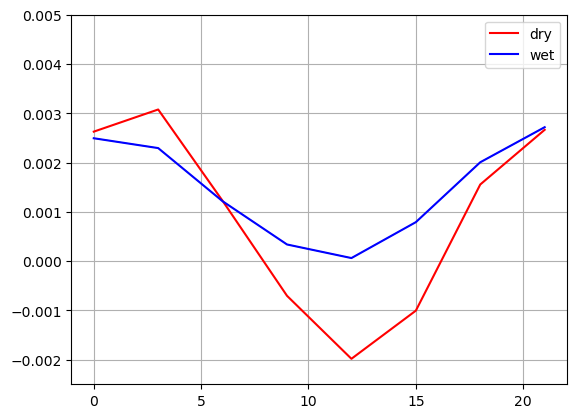

In [21]:
plt.plot(range(0,24)[::3], diurnal_sfc_term_dry, label='dry', color='red')

# plt.plot(range(0,24)[::3], diurnal_sfc_term_dry_b4, label='dryb4', color='red', linestyle='--')

plt.plot(range(0,24)[::3], diurnal_sfc_term_wet, label='wet', color='blue')

plt.fill_between(range(0,24)[::3], diurnal_sfc_term_wet + diurnal_sfc_term_wet_se, diurnal_sfc_term_wet - diurnal_sfc_term_wet_se)

# plt.plot(range(0,24)[::3], diurnal_sfc_term_wet_b4, label='wetb4', color='blue', linestyle='--')

plt.legend()

plt.ylim(-0.0025,0.005)

plt.grid()

plt.show()

In [25]:
with open('/home/annierosen16/diurnal_sfc_term_1979_2025.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': diurnal_sfc_term_dry,
        
        'wet': diurnal_sfc_term_wet
    
    }, f)
    
with open('/home/annierosen16/diurnal_sfc_term_1979_2025_std.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': diurnal_sfc_term_dry_std,
        
        'wet': diurnal_sfc_term_wet_std
    
    }, f)